# Analyzing Gallstones Disease Medical Data

Rin Hwang 

Data 101

April 10, 2026

## Introduction

In this project, I explored a Gallstone dataset that contains 319 individuals' information on 38 features of demographic information, physical measurements, and biochemical markers, all recorded from June 2022–June 2023. The research question I am investigating is: Is there a statistically significant difference in the mean Vitamin D levels between patients diagnosed with gallstone disease versus those who were not? 

This analysis examines the potential relationship between Vitamin D levels and the development of Gallstone Disease. By comparing serum Vitamin D concentrations in patients with and without a diagnosis of gallstones, the project seeks to determine if a statistically significant deficiency or variance exists that could serve as a risk factor. This is particularly relevant as Vitamin D is known to influence bile composition and gallbladder activity (Miao et al., 2023). 

The source of this data comes from the University of California, Irvine Machine Learning Repository. This dataset is uniquely appropriate for this research question because it contains verified clinical outcomes with specific nutritional and physiological biomarkers. Unlike general health surveys, this dataset specifically targets the intersection of body composition and biochemical markers in the context of gallbladder health. 

Link to dataset: https://archive.ics.uci.edu/dataset/1150/gallstone-1

I used the following variables from the dataset to effectively examine my research question:

- "Gallstone Status" (Target Variable): A categorical indicator for whether the patient has or does not have gallstones (0 for presence, 1 for absence). It divides the study population into two groups: the "Gallstone" group and the "Healthy Control"/not diagnosed with gallstone disease group.

- "Vitamin D": A continuous quantitative variable representing the serum concentration of Vitamin D of the patient.

### Importing libraries and dataset

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
from scipy import stats

In [55]:
df = pd.read_csv("C:/Users/hwang/OneDrive/Documents/MC stuff/Spring 2026/DATA 101 Introduction to Data Science/Projects/Project 2/dataset-uci.csv")

### Getting variable info

In [56]:
df.head()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

## Data Analysis

In the data analysis, I utilized two data wrangling techniques: data selection and filtering and grouping and aggregation. By using data selection, the dataset only selected the "Gallstone Status" and "Vitamin D" variables and eliminated the unused and irrelevant variables, making the dataset more clean and less likely to have errors. I also used data filtering to filter out any missing data and only have valid values. Next, I used grouping and aggregation to group the means of Vitamin D concentration levels with the two groups: "Gallstone" and "Healthy Control". This was helpful for preparing and proceeding to the statistical test.

### Data Selection and Filtering

In [58]:
selected_df = df[['Gallstone Status','Vitamin D']]

filtered_df = selected_df[selected_df['Vitamin D'] > 0]

print(filtered_df)

     Gallstone Status  Vitamin D
0                   0       33.0
1                   0       25.0
2                   0       30.2
3                   0       35.4
4                   0       40.6
..                ...        ...
314                 1        8.3
315                 1       24.0
316                 1       15.7
317                 1       33.3
318                 1       29.0

[319 rows x 2 columns]


### Data Grouping and Aggregation

0 = Presence of Gallstones

1 = Absence of Gallstones

In [59]:
mean_status = filtered_df.groupby('Gallstone Status')['Vitamin D'].mean()

print(mean_status)

Gallstone Status
0    24.904969
1    17.831329
Name: Vitamin D, dtype: float64


## Statistical Inference

### Difference in Means Test

The most appropriate test for this research question is using a Difference in Means Test since it is the most effective test to compare a continuous quantitative variable with distinct categorical groups.
In this research context, the null hypothesis means there is NO statistically significant difference in the mean Vitamin D levels between patients with gallstones and healthy controls. The Alternative Hypothesis means there IS a statistically significant difference in the mean Vitamin D levels between patients with gallstones and healthy controls.

#### Hypotheses

$\mu_1$ = The true average Vitamin D level for all people who have gallstone disease.

$\mu_2$ = The true average Vitamin D level for all people who do not have gallstone disease.

Null Hypothesis ($H_0$): $\mu_1 = \mu_2$

Alternative Hypothesis ($H_a$): $\mu_1 \neq \mu_2$ 

#### Performing the test

In [60]:
vit_d_gallstone = df[df['Gallstone Status'] == 1]['Vitamin D']
vit_d_healthy = df[df['Gallstone Status'] == 0]['Vitamin D']

t_stat, p_val = stats.ttest_ind(vit_d_gallstone, vit_d_healthy, equal_var=False)

print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.10f}")

# Standard Significance level
alpha = 0.05

if p_val < alpha:
    print(f"Reject H0: There is a significant difference in Vitamin D levels (p < {alpha})")
else:
    print(f"Fail to reject H0: No significant difference in Vitamin D levels (p > {alpha})")

t-statistic: -6.755, p-value: 0.0000000001
Reject H0: There is a significant difference in Vitamin D levels (p < 0.05)


#### Visualization 

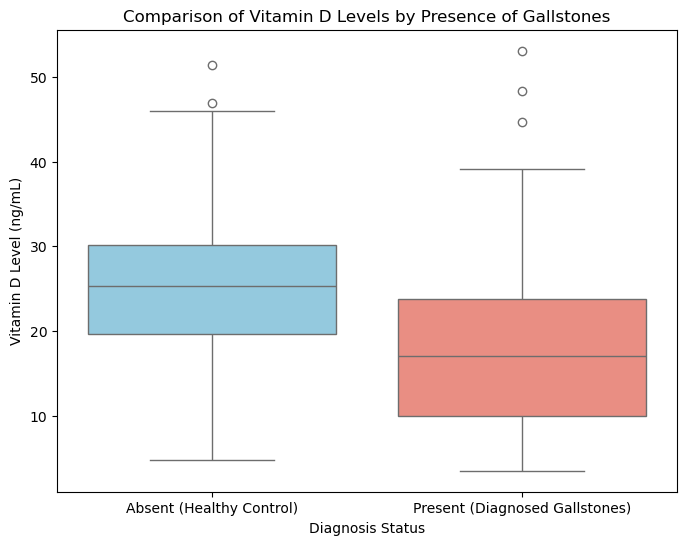

In [61]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gallstone Status', y='Vitamin D', hue='Gallstone Status', palette={0: 'skyblue', 1: 'salmon'}, legend=False)
plt.xticks([0, 1], ['Absent (Healthy Control)', 'Present (Diagnosed Gallstones)'])
plt.ylabel('Vitamin D Level (ng/mL)')
plt.xlabel('Diagnosis Status')
plt.title('Comparison of Vitamin D Levels by Presence of Gallstones')
plt.show()

#### Interpretation of Results

P-value (0.0000000001): The p-value is highly significant. Therefore, since this is much lower than the standard alpha of 0.05, there is strong evidence to reject the Null Hypothesis and the data is unlikely to have occurred by random chance.

T-Statistic (-6.755): The t-statistic determines if there is a significant difference between the means of two groups. In this context, a -6.755 is massive and has high significance, it shows the gap between the two groups on the Vitamin D levels scale is very wide. Additionally, a negative t-stat means the Gallstone group has lower Vitamin D levels than the healthy control group. 

The boxplot shows the statistically significant difference identified by the independent T-test. The median Vitamin D level for the Gallstones present group (about 17.8 ng/mL) sits well below the 25th percentile of the healthy control group, indicating a prevalent deficiency across the Gallstones present population. Furthermore, the presence of outliers suggests that while Vitamin D levels are a primary characteristic of potential development of Gallstones, it may interact with other physiological variables to determine overall risk.

Thus, there is strong evidence that a real relationship exists in this dataset. The Vitamin D levels in Gallstone patients are statistically distinct and lower than those in the healthy control group. This suggests that Vitamin D deficiency is a strong biomarker for gallstone disease.

## Conclusion and Future Directions

The primary objective of this data analysis of Gallstones Disease data was to determine if a statistically significant difference exists in mean Vitamin D levels between individuals with gallstone disease and those who do not. The results of the independent samples t-test demonstrate that patients diagnosed with gallstones exhibit significantly lower Vitamin D concentrations than their healthy counterparts. With a t-statistic of -6.755 and a p-value of 0.0000000001, which is practically zero, we reject the null hypothesis. The boxplot visualization reinforces this, showing a clear difference in median levels from approximately 25 ng/mL in the healthy group to 18 ng/mL in the clinical group. This apparent separation indicates that Vitamin D levels are a biological marker associated with the presence of Gallstone disease. 

These results are meaningful because finding such a high degree of statistical significance indicates that Vitamin D deficiency could potentially serve as a predictive biomarker for gallbladder health. This has implications for preventative medicine as it can suggest that Vitamin D screening and supplementation can benefit populations at high risk for Gallstone disease, and further research into these biological relationships can improve outcomes as well across long-term trends. 

While these findings establish a strong correlation, they do not confirm causation. Thus, to build upon this work, future research could look at a multivariate analysis by integrating other variables that may influence Gallstones diagnosis. For example, looking at the Total Body Fat Ratio (TBFR) through a multiple regression model could determine if body fat acts as a mechanism where if high body fat leads to lower Vitamin D, which then triggers gallstones. Looking at other potential cofactor variables such as cholesterol and glucose levels would be interesting and beneficial as well.

## References

Esen, I., Arslan, H., Aktürk, S., Gülşen, M., Kültekin, N., & Özdemir, O. (2024). Gallstone [Dataset]. UCI Machine Learning Repository. https://doi.org/10.1097/md.0000000000037258. 

Miao, C., Xiao, L., Xu, X., Huang, S., Liu, J., & Chen, K. (2023). Circulating vitamin levels mediate the causal relationship between gut microbiota and cholecystitis: a two-step bidirectional Mendelian randomization study. Frontiers in Nutrition, 10. https://doi.org/10.3389/fnut.2023.1268893. 